   review_id product_category  rating sentiment_label  \
0          1            chuột       2        negative   
1          2          áo thun       5        positive   
2          3     sạc dự phòng       4        positive   
3          4         tai nghe       5        positive   
4          5          áo thun       5        positive   

                                      review_text        date  
0                     size bị lệch, mặc không vừa  2026-03-09  
1  giao hàng siêu nhanh, mới đặt hôm qua nay nhận  2026-01-06  
2                đúng mẫu, màu đẹp, rất đáng tiền  2026-02-10  
3     giao nhanh, chất lượng rất ổn trong tầm giá  2026-01-28  
4       sản phẩm dùng tốt, shop tư vấn nhiệt tình  2026-03-12  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_id         100 non-null    int64 
 1   product_category  100 non-n

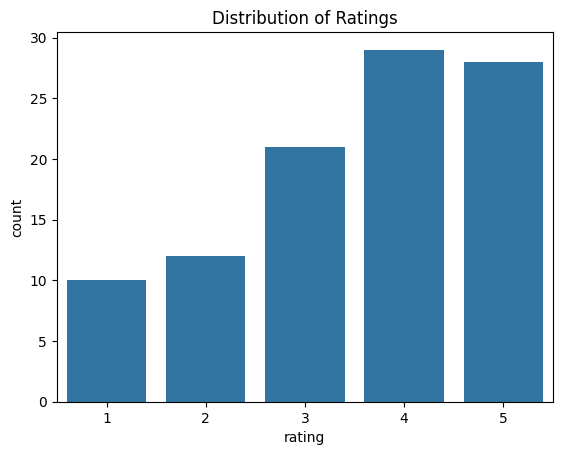

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
#Đọc dữ liệu từ file CSV
df = pd.read_csv('../data/shopee_reviews_100_comments.csv')
print(df.head())
print(df.info())



#3 kiểm tra xem có bao nhiêu review theo số sao(1 - 5 sao)
sns.countplot(x='rating', data=df)
plt.title('Distribution of Ratings')
plt.show()

In [ ]:
import pandas as pd
import os
BASE_DIR = os.path.dirname(os.path.dirname(__file__))
file_path = os.path.join(BASE_DIR, "data", "processed_reviews.csv")
df = pd.read_csv(file_path)

X = df["clean_comment"].values
y = df["sentiment_label"].values

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

with open(os.path.join(BASE_DIR, "model", "model.pkl"), "wb") as f:
    pickle.dump(model, f)

with open(os.path.join(BASE_DIR, "model", "vectorizer.pkl"), "wb") as f:
    pickle.dump(vectorizer, f)
    